# Projet 2 : Données cartographiques concernant l'épidémie de COVID-19

**Objectif** : créer des cartes dynamiques à partir des données cartographiques de l'épidémie COVID-19 en France.

L'information officielle sur la progression de l'épidémie a été initialement fragmentée. Plusieurs initiatives ont structuré les données au format GeoJSON. Nous utilisons ici les données ouvertes de Santé Publique France (data.gouv.fr) jointes aux contours géographiques officiels (régions et départements).

**Tâches** :
1. **Classification non supervisée** (clustering) pour identifier des zones géographiques homogènes
2. **Visualisation** sur cartes dynamiques (folium)
3. **Carte synchronisée** (Dual Map) — point fort apprécié
4. **Bonus** : corrélation entre vaccination et progression de la COVID-19

**Sources** :
- Contours GeoJSON : `gregoiredavid/france-geojson` (GitHub)
- Données hospitalisations SPF : data.gouv.fr (`donnees-hospitalieres-relatives-a-lepidemie-de-covid-19`)
- Données vaccination SPF (optionnel)


## Section 0 — Imports et configuration

In [1]:
import warnings
import json
import requests
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import folium
from folium import Choropleth, GeoJson
from folium.plugins import DualMap, MiniMap, Fullscreen

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

from IPython.display import display, IFrame, HTML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('folium', folium.__version__)
print('geopandas', gpd.__version__)
print('Imports OK')


folium 0.20.0
geopandas 1.1.3
Imports OK


## Section 1 — Chargement des données

### 1.1 Contours géographiques (GeoJSON)

Source : `https://github.com/gregoiredavid/france-geojson` — référentiel stable et bien maintenu des contours des régions et départements français.

> **Note** : la spec d'origine mentionnait le projet Kalisio (`kalisio/covid-19`), mais cette source n'est plus disponible (404). On utilise donc gregoiredavid comme source primaire et on joint les métriques COVID séparément depuis SPF.


In [2]:
GEO_REGIONS_URL = 'https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions.geojson'
GEO_DEPTS_URL   = 'https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson'


def load_geojson(url, label=''):
    """Telecharge et charge un GeoJSON depuis une URL en GeoDataFrame."""
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        # Forcer encodage UTF-8 (les noms de regions contiennent des accents)
        r.encoding = 'utf-8'
        gdf = gpd.read_file(StringIO(r.text))
        if gdf.crs is None or (gdf.crs.to_epsg() if gdf.crs else None) != 4326:
            gdf = gdf.set_crs(epsg=4326) if gdf.crs is None else gdf.to_crs(epsg=4326)
        print(f'[OK] {label}: {len(gdf)} features chargees')
        return gdf
    except Exception as e:
        print(f'[ERREUR] {label}: {e}')
        return None


gdf_regions = load_geojson(GEO_REGIONS_URL, 'Regions')
gdf_depts   = load_geojson(GEO_DEPTS_URL, 'Departements')

display(gdf_regions.head(3))


[OK] Regions: 13 features chargees


[OK] Departements: 96 features chargees


,code,nom,geometry
0,11,Île-de-France,"POLYGON ((2.59052 49.07965, 2.59602 49.08171, ..."
1,24,Centre-Val de Loire,"POLYGON ((2.87463 47.52042, 2.87984 47.51671, ..."
2,27,Bourgogne-Franche-Comté,"POLYGON ((3.62942 46.74946, 3.62655 46.75228, ..."


### 1.2 Données épidémiques (Santé Publique France)

Source : `donnees-hospitalieres-relatives-a-lepidemie-de-covid-19` sur data.gouv.fr — séries temporelles quotidiennes par département.

**Colonnes** : `dep`, `sexe` (0=tous, 1=H, 2=F), `jour`, `hosp` (hospitalisés), `rea` (réanimation), `rad` (retours à domicile), `dc` (décès cumulés).


In [3]:
SPF_HOSP_URL = 'https://www.data.gouv.fr/fr/datasets/r/63352e38-d353-4b54-bfd1-f1b3ee1cabd7'

print('Telechargement des donnees SPF...')
df_hosp = pd.read_csv(SPF_HOSP_URL, sep=';', parse_dates=['jour'],
                      dtype={'dep': str}, na_values=['NA'])
print(f'Shape : {df_hosp.shape}')
print(f'Periode : {df_hosp["jour"].min()} -> {df_hosp["jour"].max()}')
print(f'Departements : {df_hosp["dep"].nunique()}')
df_hosp.head()


Telechargement des donnees SPF...


Shape : (338245, 10)
Periode : 2020-03-18 00:00:00 -> 2023-03-31 00:00:00
Departements : 102


,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
0,01,0,2020-03-18,2,0,NaN,NaN,NaN,1,0
1,01,1,2020-03-18,1,0,NaN,NaN,NaN,1,0
2,01,2,2020-03-18,1,0,NaN,NaN,NaN,0,0
3,02,0,2020-03-18,41,10,NaN,NaN,NaN,18,11
4,02,1,2020-03-18,19,4,NaN,NaN,NaN,11,6


In [4]:
# Filtrer sur sexe=0 (total) et agreger : etat le plus recent par departement
df_total = df_hosp[df_hosp['sexe'] == 0].copy()
latest_date = df_total['jour'].max()
df_latest = df_total[df_total['jour'] == latest_date].copy()

# Agreger aussi les indicateurs cumules sur toute la periode
df_cumul = df_total.groupby('dep').agg(
    hosp_max=('hosp', 'max'),
    rea_max=('rea', 'max'),
    dc_cumul=('dc', 'max'),       # dc dans SPF est deja cumule
    rad_cumul=('rad', 'max'),     # idem pour les retours a domicile
).reset_index()

print(f'Date la plus recente : {latest_date.date()}')
print(f'Indicateurs cumules : {df_cumul.shape}')
df_cumul.head()


Date la plus recente : 2023-03-31
Indicateurs cumules : (102, 5)


,dep,hosp_max,rea_max,dc_cumul,rad_cumul
0,01,453,39,841,4840
1,02,346,63,1642,8723
2,03,282,29,940,6150
3,04,192,15,394,2685
4,05,191,25,412,3111


## Section 2 — Jointure et préparation

Les contours `gregoiredavid` utilisent des codes département à 2 chiffres (`'01'`, `'02'`, ... `'2A'`, `'2B'`, ...). On joint sur `code` (côté GeoDataFrame) ⇔ `dep` (côté SPF).

Pour les régions, on agrège les métriques départementales en sommant par région via la table de correspondance officielle.


In [5]:
# Verifier les codes
print('Codes departements (geojson) :', sorted(gdf_depts['code'].unique())[:10], '...')
print('Codes departements (SPF) :', sorted(df_cumul['dep'].unique())[:10], '...')

# Jointure depts
gdf_depts_full = gdf_depts.merge(df_cumul, left_on='code', right_on='dep', how='left')
gdf_depts_full = gdf_depts_full.fillna({'hosp_max': 0, 'rea_max': 0, 'dc_cumul': 0, 'rad_cumul': 0})

print(f'\nDepartements joints : {gdf_depts_full.shape}')
display(gdf_depts_full[['code', 'nom', 'hosp_max', 'rea_max', 'dc_cumul', 'rad_cumul']].head())


Codes departements (geojson) : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10'] ...
Codes departements (SPF) : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10'] ...

Departements joints : (96, 8)


,code,nom,hosp_max,rea_max,dc_cumul,rad_cumul
0,01,Ain,453,39,841,4840
1,02,Aisne,346,63,1642,8723
2,03,Allier,282,29,940,6150
3,04,Alpes-de-Haute-Provence,192,15,394,2685
4,05,Hautes-Alpes,191,25,412,3111


In [6]:
# Correspondance departement -> region (codes INSEE officiels)
DEPT_TO_REGION = {
    # Auvergne-Rhone-Alpes (84)
    **{d: '84' for d in ['01','03','07','15','26','38','42','43','63','69','73','74']},
    # Bourgogne-Franche-Comte (27)
    **{d: '27' for d in ['21','25','39','58','70','71','89','90']},
    # Bretagne (53)
    **{d: '53' for d in ['22','29','35','56']},
    # Centre-Val de Loire (24)
    **{d: '24' for d in ['18','28','36','37','41','45']},
    # Corse (94)
    **{d: '94' for d in ['2A','2B']},
    # Grand Est (44)
    **{d: '44' for d in ['08','10','51','52','54','55','57','67','68','88']},
    # Hauts-de-France (32)
    **{d: '32' for d in ['02','59','60','62','80']},
    # Ile-de-France (11)
    **{d: '11' for d in ['75','77','78','91','92','93','94','95']},
    # Normandie (28)
    **{d: '28' for d in ['14','27','50','61','76']},
    # Nouvelle-Aquitaine (75)
    **{d: '75' for d in ['16','17','19','23','24','33','40','47','64','79','86','87']},
    # Occitanie (76)
    **{d: '76' for d in ['09','11','12','30','31','32','34','46','48','65','66','81','82']},
    # Pays de la Loire (52)
    **{d: '52' for d in ['44','49','53','72','85']},
    # PACA (93)
    **{d: '93' for d in ['04','05','06','13','83','84']},
}

df_cumul['region_code'] = df_cumul['dep'].map(DEPT_TO_REGION)
df_reg_agg = df_cumul.groupby('region_code').agg(
    hosp_max=('hosp_max', 'sum'),
    rea_max=('rea_max', 'sum'),
    dc_cumul=('dc_cumul', 'sum'),
    rad_cumul=('rad_cumul', 'sum'),
).reset_index()

gdf_regions_full = gdf_regions.merge(df_reg_agg, left_on='code', right_on='region_code', how='left')
gdf_regions_full = gdf_regions_full.fillna({'hosp_max': 0, 'rea_max': 0, 'dc_cumul': 0, 'rad_cumul': 0})

print(f'Regions jointes : {gdf_regions_full.shape}')
display(gdf_regions_full[['code', 'nom', 'hosp_max', 'rea_max', 'dc_cumul', 'rad_cumul']])


Regions jointes : (13, 8)


,code,nom,hosp_max,rea_max,dc_cumul,rad_cumul
0,11,Île-de-France,13328,2737,28794,177825
1,24,Centre-Val de Loire,1511,244,4530,29397
2,27,Bourgogne-Franche-Comté,2283,343,7350,43989
3,28,Normandie,2121,255,5566,37166
4,32,Hauts-de-France,3963,749,13677,79559
5,44,Grand Est,5372,1013,14761,79860
6,52,Pays de la Loire,1316,205,4646,34269
7,53,Bretagne,1407,160,3633,31342
8,75,Nouvelle-Aquitaine,2834,373,7803,53743
9,76,Occitanie,3203,532,9212,62322


## Section 3 — Analyse Exploratoire des Données Géographiques


In [7]:
# Statistiques descriptives
print('=== REGIONS ===')
display(gdf_regions_full[['hosp_max', 'rea_max', 'dc_cumul', 'rad_cumul']].describe())
print('\n=== DEPARTEMENTS ===')
display(gdf_depts_full[['hosp_max', 'rea_max', 'dc_cumul', 'rad_cumul']].describe())


=== REGIONS ===


,hosp_max,rea_max,dc_cumul,rad_cumul
count,13.000000,13.000000,13.000000,13.000000
mean,3750.923077,634.923077,10177.000000,64369.384615
std,3432.802219,701.248109,7557.744086,45101.961847
min,224.000000,37.000000,521.000000,3762.000000
25%,1511.000000,244.000000,4646.000000,34269.000000
50%,2834.000000,373.000000,7803.000000,53743.000000
75%,3965.000000,749.000000,14228.000000,79860.000000
max,13328.000000,2737.000000,28794.000000,177825.000000



=== DEPARTEMENTS ===


,hosp_max,rea_max,dc_cumul,rad_cumul
count,96.000000,96.000000,96.000000,96.00000
mean,507.937500,85.979167,1378.135417,8716.68750
std,540.239359,120.513461,1297.697634,8386.31126
min,58.000000,7.000000,164.000000,785.00000
25%,194.750000,21.500000,518.250000,3354.25000
50%,295.000000,39.500000,888.000000,5596.50000
75%,562.000000,90.500000,1694.750000,10986.75000
max,3281.000000,855.000000,6463.000000,48210.00000


In [8]:
# Top 10 departements les plus impactes (deces cumules)
top10 = gdf_depts_full.nlargest(10, 'dc_cumul')[['code', 'nom', 'hosp_max', 'rea_max', 'dc_cumul']]
print('Top 10 departements par deces cumules :')
display(top10)


Top 10 departements par deces cumules :


,code,nom,hosp_max,rea_max,dc_cumul
75,75,Paris,3281,855,6463
14,13,Bouches-du-Rhône,1649,354,6230
59,59,Nord,1692,362,6029
69,69,Rhône,1913,304,4546
94,94,Val-de-Marne,2278,344,4105
92,92,Hauts-de-Seine,2024,456,3661
57,57,Moselle,1071,181,3339
93,93,Seine-Saint-Denis,1638,251,3220
77,77,Seine-et-Marne,845,213,3066
83,83,Var,651,89,2859


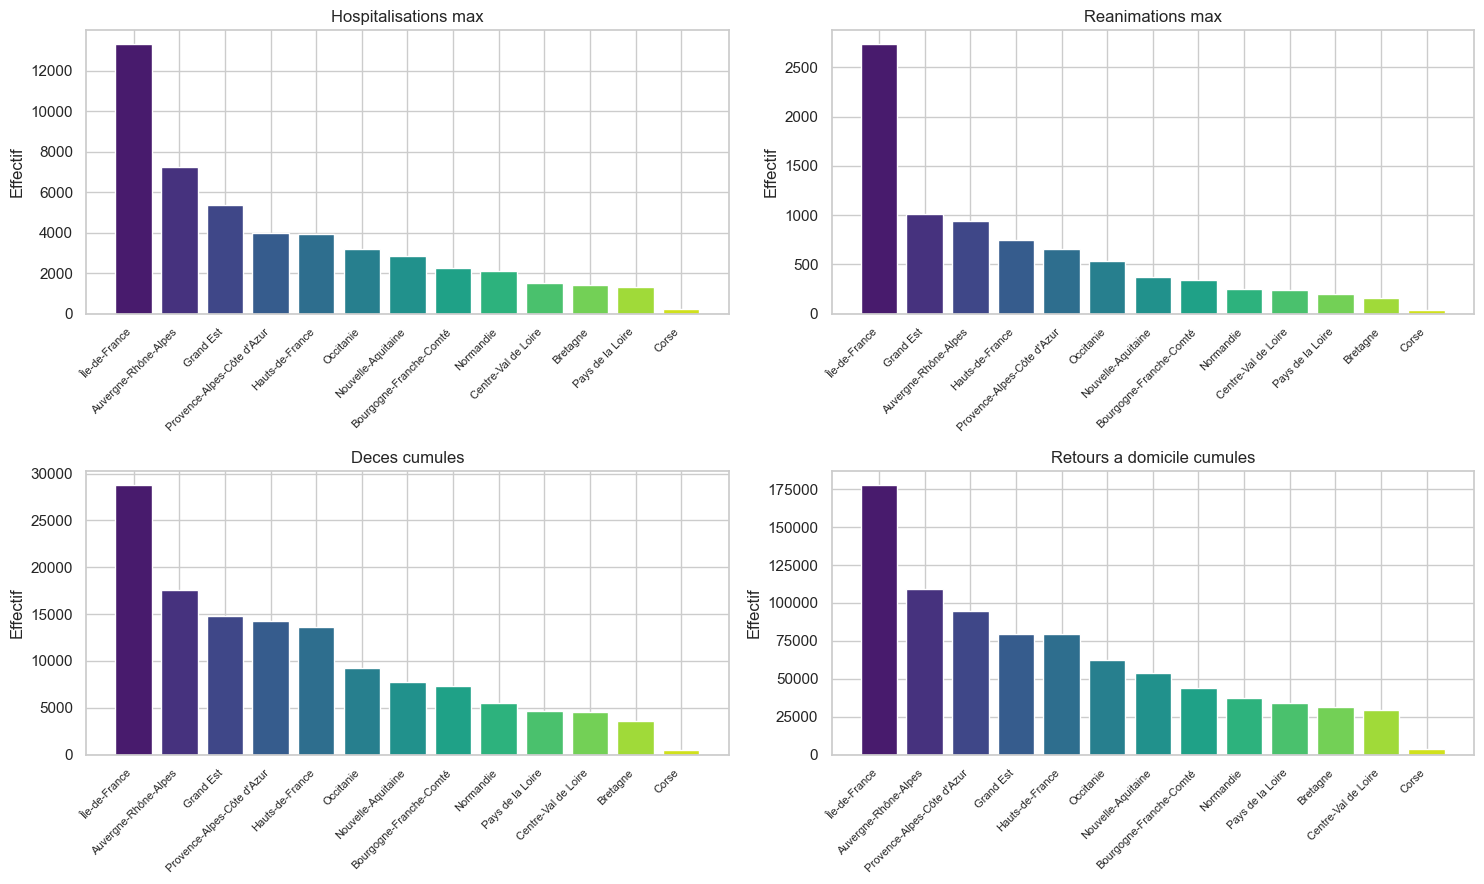

In [9]:
# Barplot regions
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
metrics = [('hosp_max', 'Hospitalisations max'),
           ('rea_max', 'Reanimations max'),
           ('dc_cumul', 'Deces cumules'),
           ('rad_cumul', 'Retours a domicile cumules')]

for ax, (col, title) in zip(axes.flat, metrics):
    data = gdf_regions_full.sort_values(col, ascending=False)
    ax.bar(range(len(data)), data[col], color=sns.color_palette('viridis', len(data)))
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['nom'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Effectif')

plt.tight_layout()
plt.show()


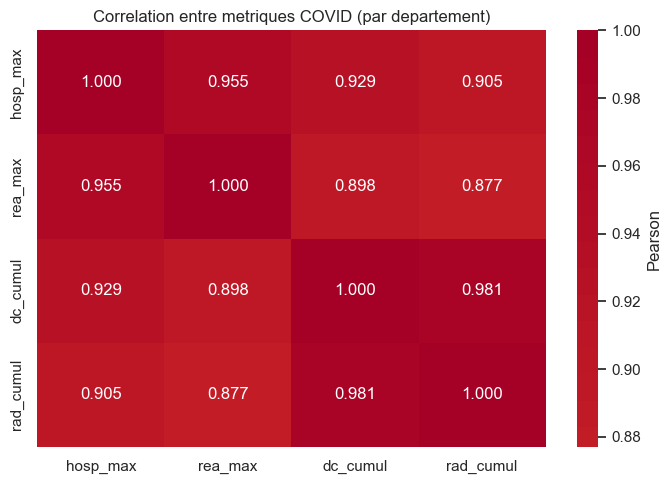

In [10]:
# Heatmap de correlation entre metriques (au niveau departement)
corr = gdf_depts_full[['hosp_max', 'rea_max', 'dc_cumul', 'rad_cumul']].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Pearson'})
ax.set_title('Correlation entre metriques COVID (par departement)')
plt.tight_layout()
plt.show()


## Section 4 — Clustering géographique non supervisé

On segmente régions et départements en clusters homogènes selon leur profil épidémique.

- **KMeans** sur métriques normalisées avec choix de `k` par silhouette
- **Clustering hiérarchique** (Ward) pour visualisation par dendrogramme


In [11]:
# Features de clustering (departements)
feat_cols = ['hosp_max', 'rea_max', 'dc_cumul', 'rad_cumul']

# Departements
X_depts = gdf_depts_full[feat_cols].fillna(0).values
scaler_d = StandardScaler()
X_depts_scaled = scaler_d.fit_transform(X_depts)

# Regions
X_regs = gdf_regions_full[feat_cols].fillna(0).values
scaler_r = StandardScaler()
X_regs_scaled = scaler_r.fit_transform(X_regs)

print(f'Departements features : {X_depts_scaled.shape}')
print(f'Regions features      : {X_regs_scaled.shape}')


Departements features : (96, 4)
Regions features      : (13, 4)


  File "C:\Users\Lucas Madjinda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lucas Madjinda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", l

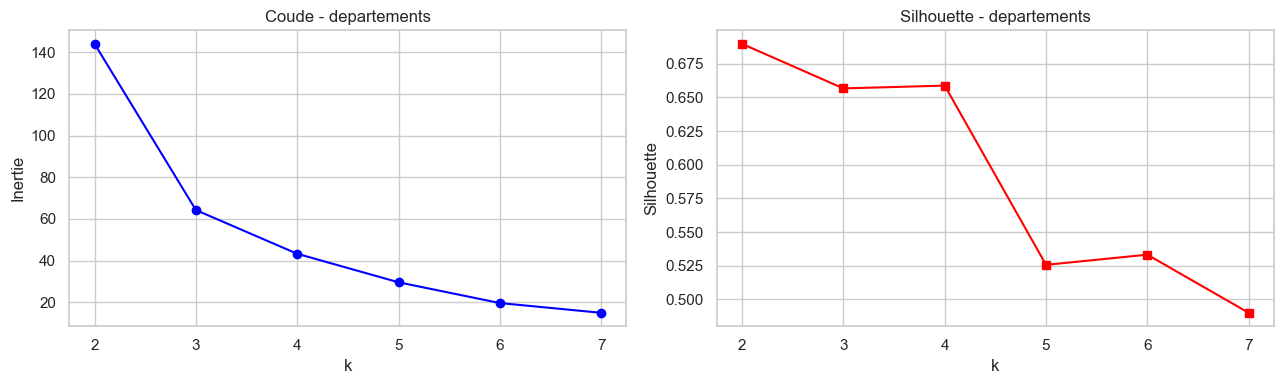

k optimal departements : 2 (silhouette = 0.690)


In [12]:
# Choix de k pour KMeans (sur departements)
K_RANGE = range(2, 8)
sils_d, inertia_d = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_depts_scaled)
    sils_d.append(silhouette_score(X_depts_scaled, labels))
    inertia_d.append(km.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(K_RANGE), inertia_d, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertie'); ax1.set_title('Coude - departements')
ax2.plot(list(K_RANGE), sils_d, 'rs-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette'); ax2.set_title('Silhouette - departements')
plt.tight_layout()
plt.show()

best_k_d = list(K_RANGE)[int(np.argmax(sils_d))]
print(f'k optimal departements : {best_k_d} (silhouette = {max(sils_d):.3f})')


In [13]:
# Application KMeans final
km_d = KMeans(n_clusters=best_k_d, random_state=RANDOM_STATE, n_init=10)
gdf_depts_full['Cluster'] = km_d.fit_predict(X_depts_scaled)

# Regions : on prend k=3 pour avoir un visuel lisible (peu de regions)
N_REG_CLUSTERS = 3
km_r = KMeans(n_clusters=N_REG_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
gdf_regions_full['Cluster'] = km_r.fit_predict(X_regs_scaled)

print(f'Distribution clusters departements (k={best_k_d}) :')
print(gdf_depts_full['Cluster'].value_counts().sort_index())
print(f'\nDistribution clusters regions (k={N_REG_CLUSTERS}) :')
print(gdf_regions_full['Cluster'].value_counts().sort_index())


Distribution clusters departements (k=2) :
Cluster
0    18
1    78
Name: count, dtype: int64

Distribution clusters regions (k=3) :
Cluster
0    8
1    1
2    4
Name: count, dtype: int64


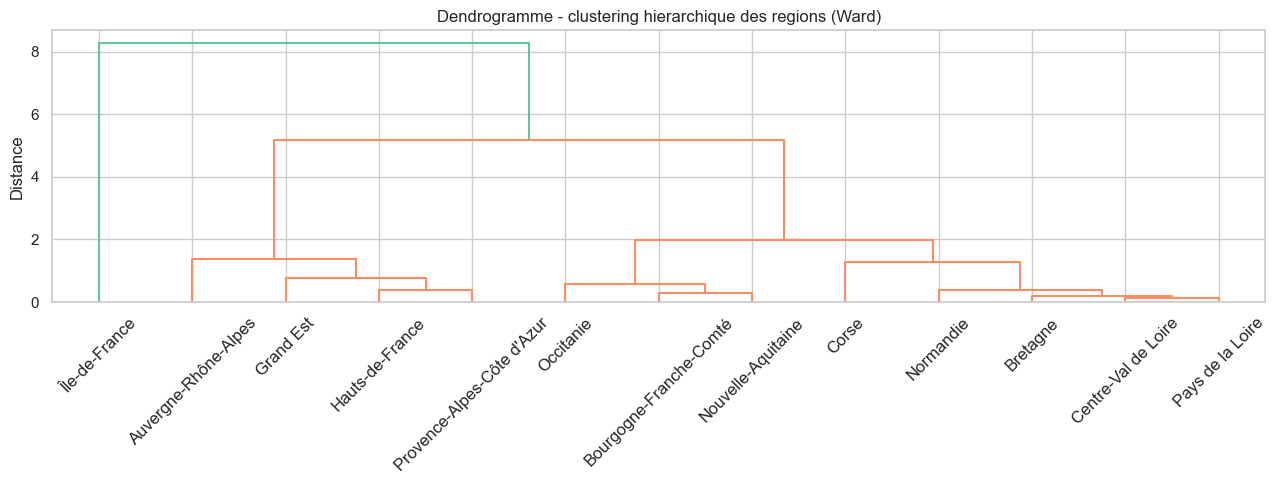

In [14]:
# Clustering hierarchique (regions) - dendrogramme
Z = linkage(X_regs_scaled, method='ward')
fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, labels=gdf_regions_full['nom'].tolist(), ax=ax, leaf_rotation=45)
ax.set_title('Dendrogramme - clustering hierarchique des regions (Ward)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


In [15]:
# Profiling des clusters de departements
profile = gdf_depts_full.groupby('Cluster').agg(
    n_depts=('code', 'count'),
    hosp_moyenne=('hosp_max', 'mean'),
    rea_moyenne=('rea_max', 'mean'),
    dc_moyens=('dc_cumul', 'mean'),
    depts_exemples=('nom', lambda x: ', '.join(x.head(3).tolist()))
).round(1)

print('Profiling des clusters (departements) :')
display(profile)


Profiling des clusters (departements) :


,n_depts,hosp_moyenne,rea_moyenne,dc_moyens,depts_exemples
Cluster,,,,,
0,18,1418.0,274.2,3571.6,"Alpes-Maritimes, Bouches-du-Rhône, Isère"
1,78,297.9,42.6,872.0,"Ain, Aisne, Allier"


## Section 5 — Cartes dynamiques (Folium)

Trois cartes sont produites :
1. **Choroplèthe régions** — décès cumulés
2. **Choroplèthe départements** — hospitalisations max
3. **Carte synchronisée** (DualMap) — comparaison côte à côte de deux indicateurs
4. **Carte des clusters** géographiques


In [16]:
def build_choropleth(gdf, metric, legend, title, output_html, cmap='YlOrRd'):
    """Construit une carte choroplethe Folium et la sauvegarde en HTML."""
    m = folium.Map(location=[46.2276, 2.2137], zoom_start=6, tiles='CartoDB positron')

    Choropleth(
        geo_data=gdf.__geo_interface__,
        data=gdf,
        columns=['code', metric],
        key_on='feature.properties.code',
        fill_color=cmap,
        fill_opacity=0.75,
        line_opacity=0.3,
        nan_fill_color='lightgray',
        legend_name=legend,
    ).add_to(m)

    GeoJson(
        gdf.__geo_interface__,
        style_function=lambda x: {'fillOpacity': 0, 'color': 'transparent'},
        tooltip=folium.GeoJsonTooltip(
            fields=['code', 'nom', metric],
            aliases=['Code :', 'Nom :', f'{legend} :'],
            localize=True
        )
    ).add_to(m)

    MiniMap(toggle_display=True).add_to(m)
    Fullscreen().add_to(m)
    folium.LayerControl().add_to(m)

    title_html = f'<h3 style="position:fixed; top:10px; left:60px; z-index:9999; \
                       background:white; padding:8px; border-radius:6px;">{title}</h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    m.save(output_html)
    print(f'Carte sauvegardee : {output_html}')
    return m


map_regions = build_choropleth(
    gdf_regions_full, 'dc_cumul', 'Deces cumules',
    'COVID-19 - Deces cumules par region', 'cartes/map_regions_deces.html'
)
display(IFrame('cartes/map_regions_deces.html', width='100%', height=500))


Carte sauvegardee : cartes/map_regions_deces.html


In [17]:
map_depts = build_choropleth(
    gdf_depts_full, 'hosp_max', 'Hospitalisations max',
    'COVID-19 - Pic hospitalisations par departement',
    'cartes/map_depts_hosp.html', cmap='YlOrRd'
)
display(IFrame('cartes/map_depts_hosp.html', width='100%', height=500))


Carte sauvegardee : cartes/map_depts_hosp.html


### 5.3 Carte synchronisée (DualMap)

Deux panneaux côte à côte avec zoom et déplacement synchronisés, permettant de comparer visuellement deux métriques.


In [18]:
dual = DualMap(location=[46.2276, 2.2137], zoom_start=6, tiles='CartoDB positron')

# Panneau gauche : hospitalisations
Choropleth(
    geo_data=gdf_regions_full.__geo_interface__,
    data=gdf_regions_full,
    columns=['code', 'hosp_max'],
    key_on='feature.properties.code',
    fill_color='Blues', fill_opacity=0.75, line_opacity=0.3,
    legend_name='Hospitalisations max',
    nan_fill_color='lightgray'
).add_to(dual.m1)
GeoJson(
    gdf_regions_full.__geo_interface__,
    style_function=lambda x: {'fillOpacity': 0, 'color': 'transparent'},
    tooltip=folium.GeoJsonTooltip(fields=['nom', 'hosp_max'],
                                  aliases=['Region :', 'Hosp :']),
).add_to(dual.m1)

# Panneau droit : deces
Choropleth(
    geo_data=gdf_regions_full.__geo_interface__,
    data=gdf_regions_full,
    columns=['code', 'dc_cumul'],
    key_on='feature.properties.code',
    fill_color='Reds', fill_opacity=0.75, line_opacity=0.3,
    legend_name='Deces cumules',
    nan_fill_color='lightgray'
).add_to(dual.m2)
GeoJson(
    gdf_regions_full.__geo_interface__,
    style_function=lambda x: {'fillOpacity': 0, 'color': 'transparent'},
    tooltip=folium.GeoJsonTooltip(fields=['nom', 'dc_cumul'],
                                  aliases=['Region :', 'Deces :']),
).add_to(dual.m2)

dual.save('cartes/dual_map.html')
print('Carte synchronisee sauvegardee : cartes/dual_map.html')
display(IFrame('cartes/dual_map.html', width='100%', height=500))


Carte synchronisee sauvegardee : cartes/dual_map.html


### 5.4 Carte des clusters

Coloration de chaque département selon son cluster d'appartenance — visualisation géographique des profils épidémiques homogènes.


In [19]:
CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

def style_cluster(feature, gdf=gdf_depts_full):
    code = feature['properties'].get('code', '')
    match = gdf.loc[gdf['code'] == code, 'Cluster']
    if len(match) == 0:
        return {'fillColor': '#cccccc', 'color': 'white', 'weight': 0.5, 'fillOpacity': 0.6}
    c = int(match.iloc[0])
    return {'fillColor': CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            'color': 'white', 'weight': 0.5, 'fillOpacity': 0.75}


m_cluster = folium.Map(location=[46.2276, 2.2137], zoom_start=6, tiles='CartoDB positron')

GeoJson(
    gdf_depts_full.__geo_interface__,
    style_function=style_cluster,
    tooltip=folium.GeoJsonTooltip(
        fields=['code', 'nom', 'Cluster', 'hosp_max', 'dc_cumul'],
        aliases=['Code :', 'Nom :', 'Cluster :', 'Hosp :', 'Deces :']
    )
).add_to(m_cluster)

# Legende manuelle
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999;
            background:white; padding:10px; border:2px solid grey; border-radius:6px;
            font-family:Arial; font-size:12px;">
  <b>Clusters epidemiques</b><br>
'''
for i in range(km_d.n_clusters):
    legend_html += f'<i style="background:{CLUSTER_COLORS[i]};width:14px;height:14px;\
                               display:inline-block;margin-right:6px;"></i>Cluster {i}<br>'
legend_html += '</div>'
m_cluster.get_root().html.add_child(folium.Element(legend_html))

MiniMap(toggle_display=True).add_to(m_cluster)
Fullscreen().add_to(m_cluster)
m_cluster.save('cartes/map_clusters.html')
print('Carte clusters sauvegardee : cartes/map_clusters.html')
display(IFrame('cartes/map_clusters.html', width='100%', height=500))


Carte clusters sauvegardee : cartes/map_clusters.html


## Section 6 — Corrélation Vaccination / COVID (bonus)

Analyse exploratoire de la relation entre couverture vaccinale et indicateurs hospitaliers, au niveau département. Données Santé Publique France.


In [20]:
VAX_URL = 'https://www.data.gouv.fr/fr/datasets/r/32a16487-3dd3-4326-9d2b-317e5a3b2daf'

try:
    print('Telechargement donnees vaccination...')
    df_vax = pd.read_csv(VAX_URL, sep=';', parse_dates=['jour'], dtype={'dep': str})
    print(f'Shape : {df_vax.shape}')
    print(f'Colonnes : {df_vax.columns.tolist()}')
    print(f'Periode : {df_vax["jour"].min().date()} -> {df_vax["jour"].max().date()}')
    df_vax.head()
except Exception as e:
    print(f'Donnees vaccination indisponibles : {e}')
    df_vax = None


Telechargement donnees vaccination...


Shape : (1136, 12)
Colonnes : ['dep', 'vaccin', 'jour', 'n_tot_dose1', 'n_tot_dose2', 'n_tot_dose3', 'n_tot_dose4', 'n_tot_complet', 'n_tot_rappel', 'n_tot_2_rappel', 'n_tot_rappel_biv', 'n_tot_3_rappel']
Periode : 2023-07-10 -> 2023-07-10


In [21]:
if df_vax is not None:
    # Agreger : dose complete maximale par departement (cumul)
    cum_col = next((c for c in df_vax.columns if 'cum' in c.lower() and 'complet' in c.lower()), None)
    if cum_col is None:
        cum_col = next((c for c in df_vax.columns if 'cum' in c.lower()), df_vax.columns[-1])
    print(f'Colonne cumul vaccinal utilisee : {cum_col}')

    df_vax_max = df_vax.groupby('dep')[cum_col].max().reset_index()
    df_vax_max.columns = ['dep', 'vaccinations_completes']

    # Joindre avec donnees hospitalieres
    df_corr = gdf_depts_full[['code', 'nom', 'hosp_max', 'rea_max', 'dc_cumul']].merge(
        df_vax_max, left_on='code', right_on='dep', how='inner'
    )
    print(f'Departements croises : {len(df_corr)}')

    # Calcul des correlations
    for metric in ['hosp_max', 'rea_max', 'dc_cumul']:
        c = df_corr['vaccinations_completes'].corr(df_corr[metric])
        print(f'  Correlation Pearson vaccination/{metric} : {c:+.3f}')
else:
    df_corr = None
    print('Section ignoree (donnees vaccination indisponibles).')


Colonne cumul vaccinal utilisee : n_tot_3_rappel
Departements croises : 96
  Correlation Pearson vaccination/hosp_max : +0.744
  Correlation Pearson vaccination/rea_max : +0.749
  Correlation Pearson vaccination/dc_cumul : +0.788


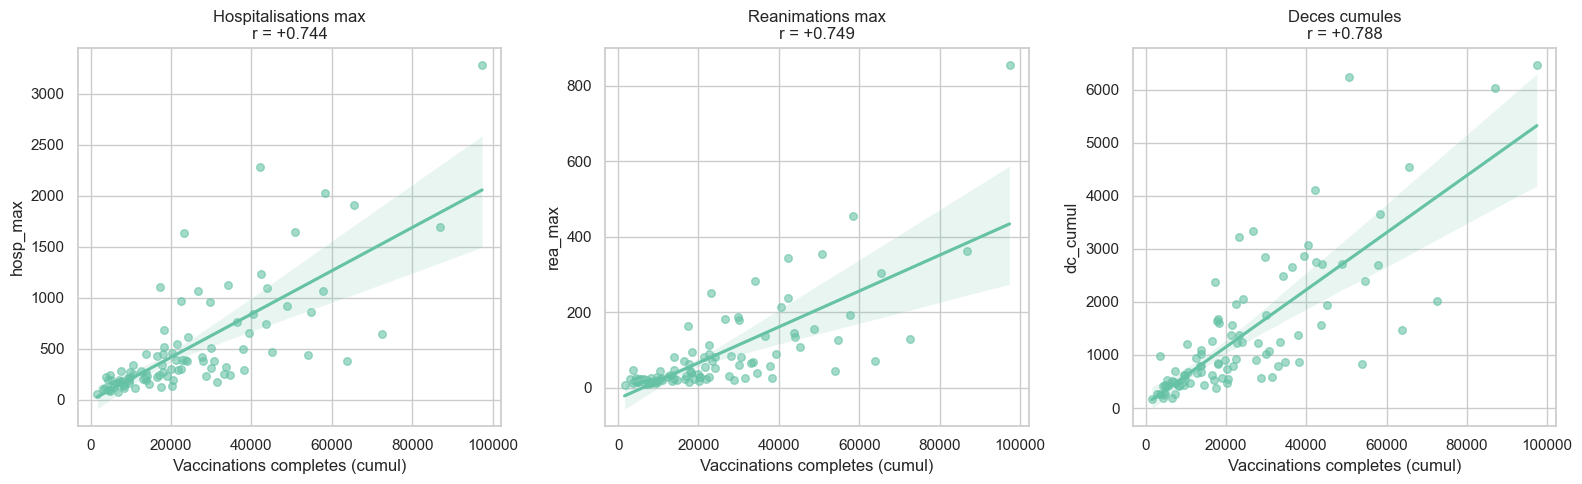

In [22]:
if df_corr is not None and len(df_corr) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric, label in zip(axes,
                                  ['hosp_max', 'rea_max', 'dc_cumul'],
                                  ['Hospitalisations max', 'Reanimations max', 'Deces cumules']):
        sns.regplot(data=df_corr, x='vaccinations_completes', y=metric,
                    ax=ax, scatter_kws={'alpha': 0.6, 's': 30})
        c = df_corr['vaccinations_completes'].corr(df_corr[metric])
        ax.set_title(f'{label}\nr = {c:+.3f}')
        ax.set_xlabel('Vaccinations completes (cumul)')
    plt.tight_layout()
    plt.show()


---

## Conclusion

Ce projet implémente une analyse cartographique complète de l'épidémie COVID-19 en France :

1. **Données** : jointure entre contours administratifs (gregoiredavid) et indicateurs hospitaliers SPF
2. **EDA** : statistiques descriptives, top régions/départements impactés, corrélations
3. **Clustering** : segmentation en zones épidémiques homogènes par KMeans et hiérarchique
4. **Cartographie interactive** : 4 cartes Folium (régions, départements, dual map synchronisée, clusters)
5. **Analyse vaccination** : corrélation départementale vaccination / sévérité épidémique

**Cartes HTML produites** : `map_regions_deces.html`, `map_depts_hosp.html`, `dual_map.html`, `map_clusters.html`

**Limites** : analyse statique sur indicateurs cumulés. Une extension serait l'animation temporelle (folium TimestampedGeoJson) pour visualiser l'évolution.
